<a href="https://colab.research.google.com/github/omarmmowena10/Customer-Shopping-Trends-Analysis/blob/main/Diamonds_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/diamonds (1).csv")

df.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53947 entries, 0 to 53946
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53947 non-null  int64  
 1   carat       53947 non-null  float64
 2   cut         53944 non-null  object 
 3   color       53946 non-null  object 
 4   clarity     53947 non-null  object 
 5   depth       53946 non-null  float64
 6   table       53947 non-null  float64
 7   price       53947 non-null  int64  
 8   x           53947 non-null  float64
 9   y           53947 non-null  float64
 10  z           53947 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 4.5+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,3
color,1
clarity,0
depth,1
table,0
price,0
x,0
y,0


In [ ]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,carat,depth,table,price,x,y
count,53794.00000,53793.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748029,57.458109,3933.008309,5.731214,5.734653
std,0.47339,1.429873,2.233679,3988.151559,1.120695,1.141209
min,0.20000,43.000000,43.000000,-200.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000


In [ ]:
df.isnull().sum()


,0
carat,0
cut,3
color,1
clarity,0
depth,1
table,0
price,0
x,0
y,0
z,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


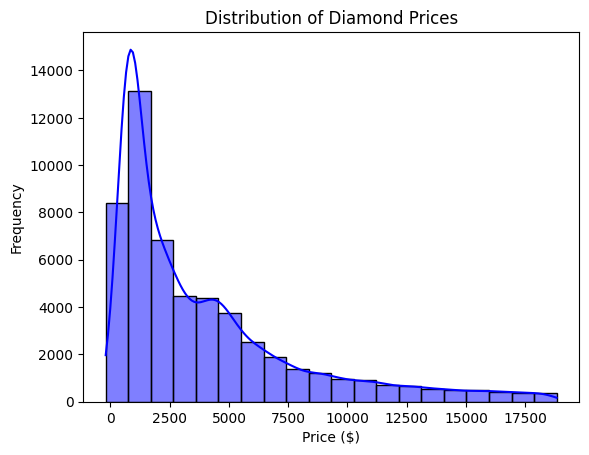

In [ ]:
sns.histplot(df['price'], bins=20, kde=True, color='blue')
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

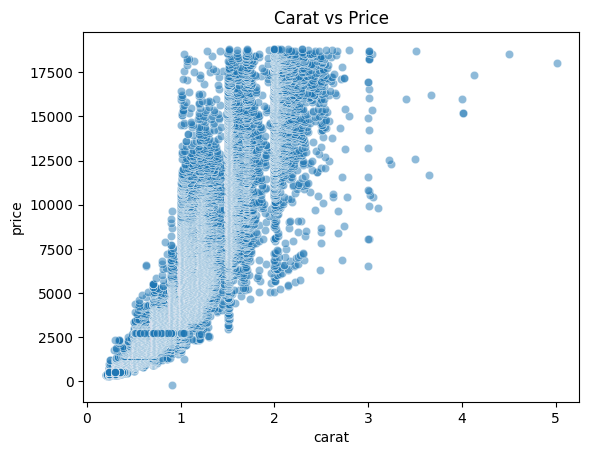

In [ ]:
sns.scatterplot(x='carat', y='price', data=df, alpha=0.5)
plt.title('Carat vs Price')
plt.show()

In [ ]:

df['cut'] = df['cut'].str.capitalize()

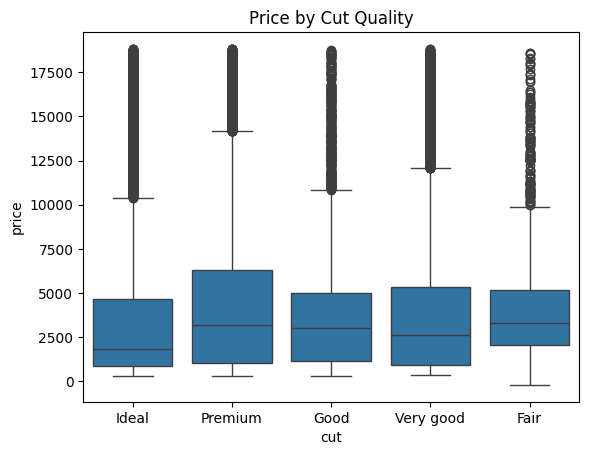

In [ ]:
sns.boxplot(x='cut', y='price', data=df)
plt.title('Price by Cut Quality')
plt.show()

In [ ]:
df = df[df['color'] != '87']

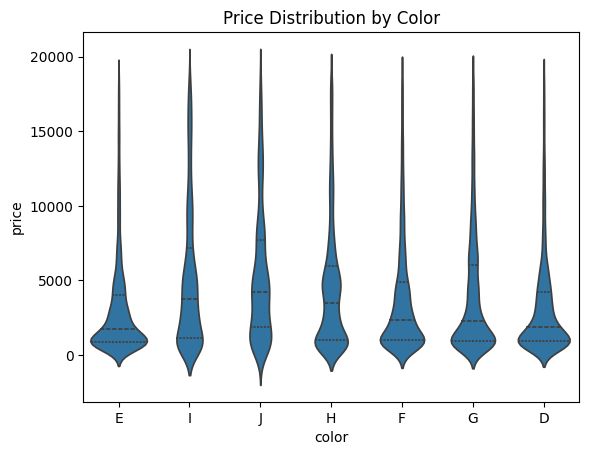

In [ ]:
sns.violinplot(data=df, x="color", y="price", inner="quartile")
plt.title("Price Distribution by Color")
plt.show()

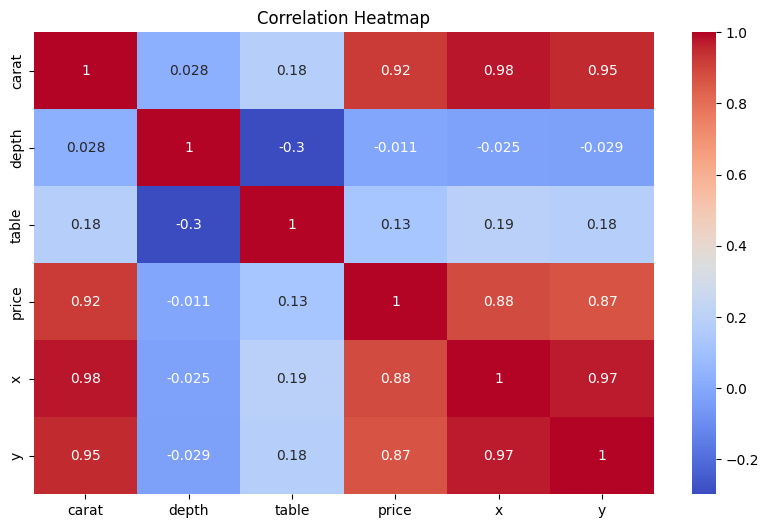

In [ ]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


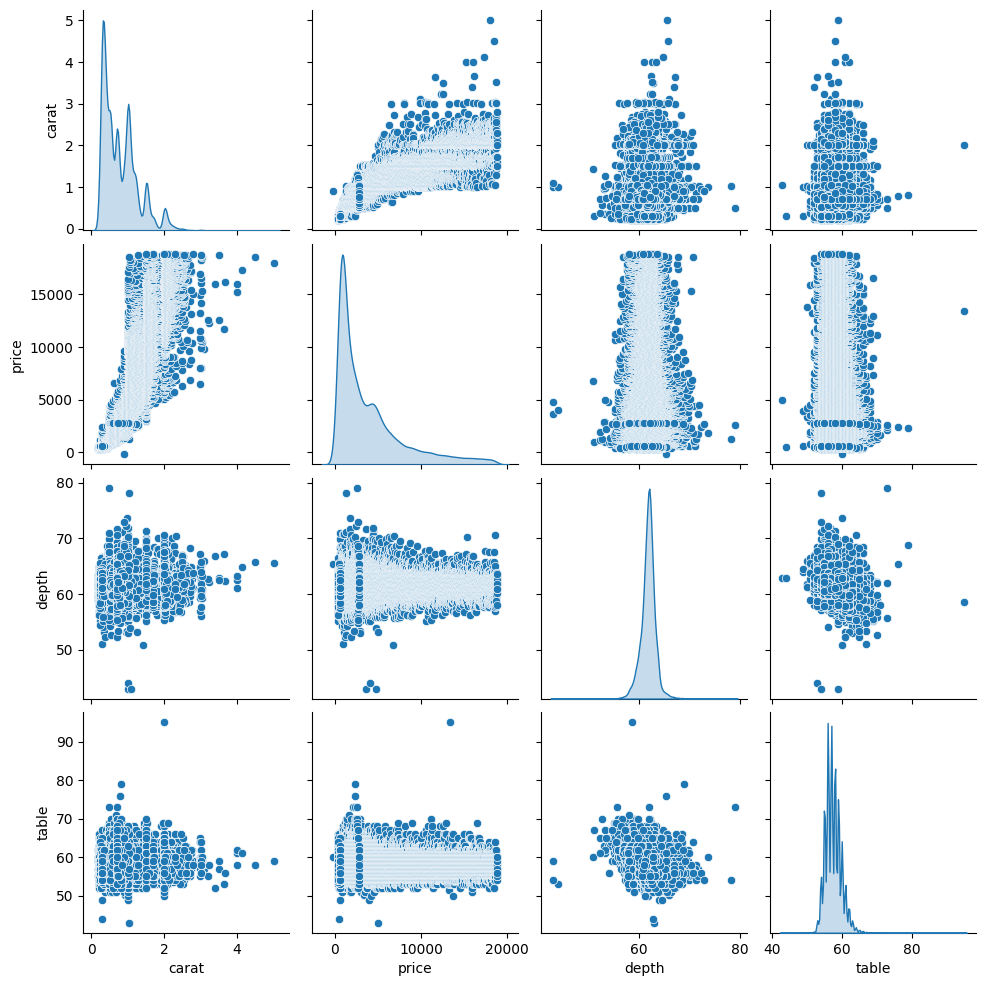

In [ ]:
sns.pairplot(
    df[["carat", "price", "depth", "table"]],
    diag_kind="kde"
)
plt.show()



In [ ]:

cols_to_fix = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for col in cols_to_fix:

    df[col] = pd.to_numeric(df[col], errors='coerce')


df.dropna(subset=cols_to_fix, inplace=True)

print(df.dtypes)

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


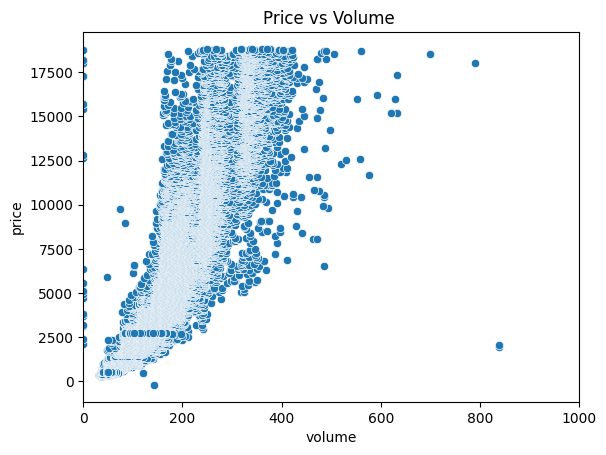

In [ ]:
sns.scatterplot(x='volume', y='price', data=df)
plt.xlim(0, 1000)
plt.title("Price vs Volume ")
plt.show()